Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



===== Antibiotic Disk 1 =====
  [Before]  text=85                   conf=0.57  angle=-90°
  [After ]  text=821                  conf=0.63  angle=-105°


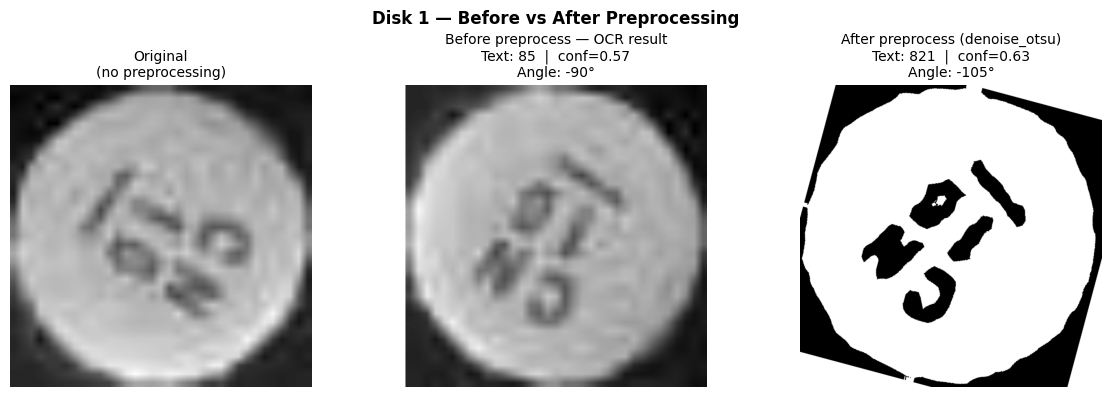


===== Antibiotic Disk 2 =====
  [Before]  text=6                    conf=0.67  angle=-15°
  [After ]  text=06 3                 conf=0.63  angle=165°


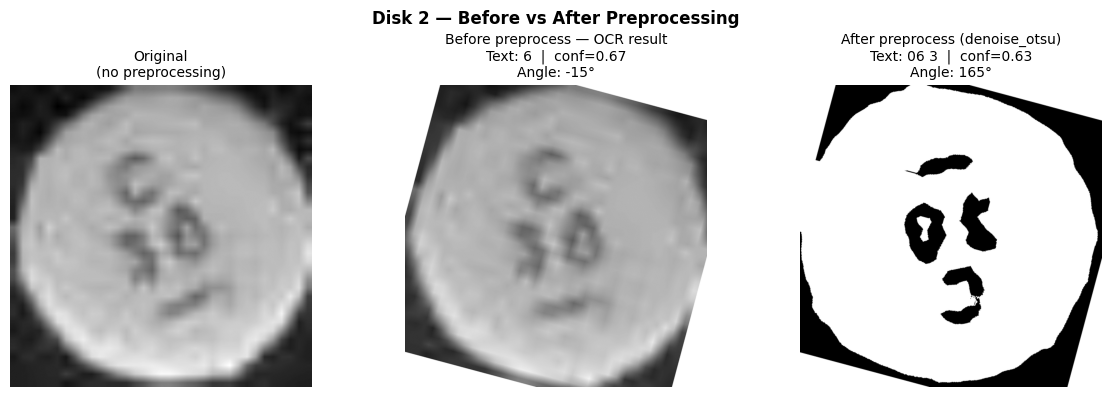


===== Antibiotic Disk 3 =====
  [Before]  text=X                    conf=0.68  angle=45°
  [After ]  text=I 8                  conf=0.54  angle=-30°


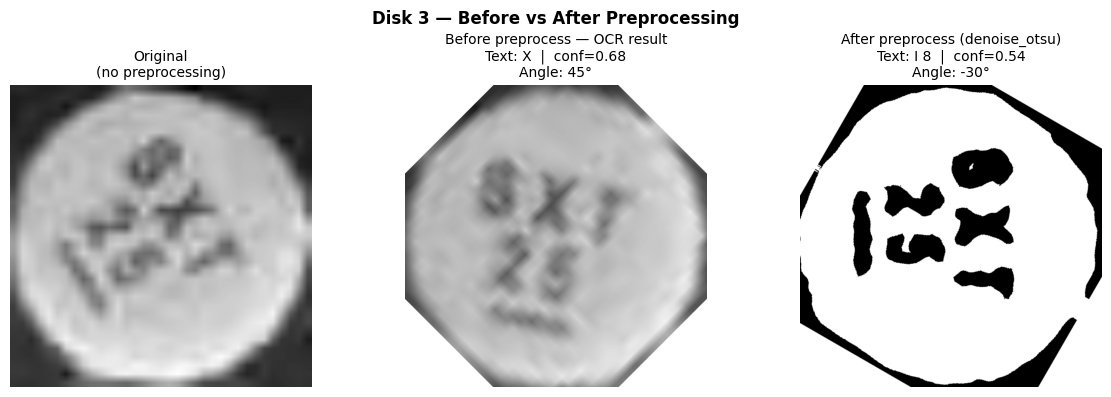


===== Antibiotic Disk 4 =====
  [Before]  text=IS7                  conf=0.29  angle=165°
  [After ]  text=6 J0                 conf=0.61  angle=-90°


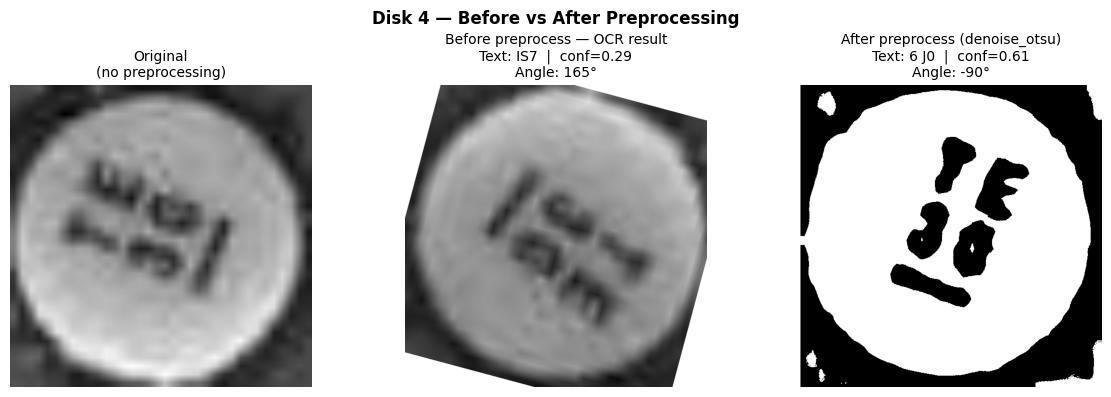


===== Antibiotic Disk 5 =====
  [Before]  text=1                    conf=0.40  angle=45°
  [After ]  text=KD 10                conf=0.73  angle=60°


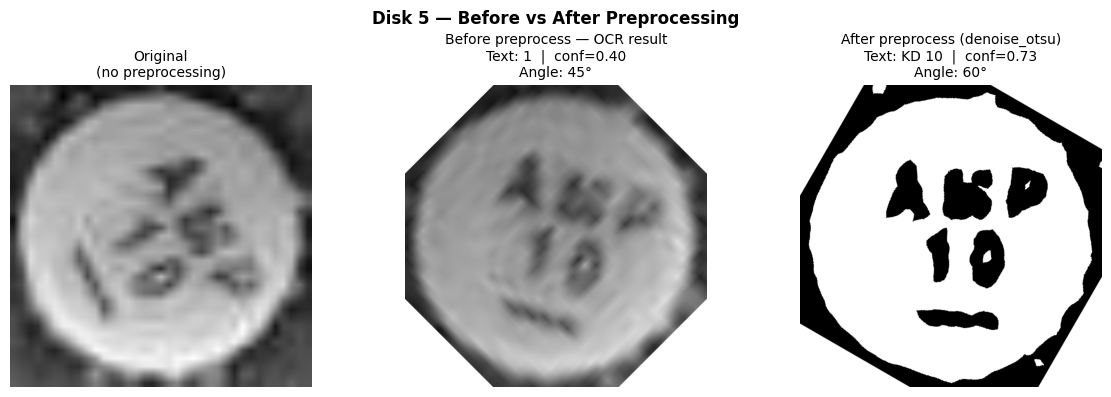


===== Antibiotic Disk 6 =====
  [Before]  text=7                    conf=0.28  angle=-135°
  [After ]  text=0                    conf=0.64  angle=-90°


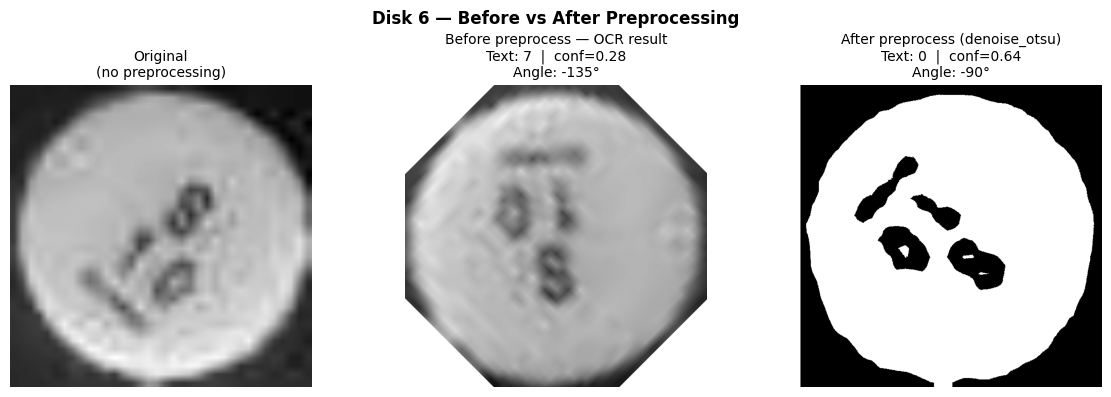

In [3]:
from preprocessing_func import *
import torch
from PIL import Image
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
import matplotlib.pyplot as plt
import cv2
import numpy as np
import easyocr
import re

# ==========================
# 1. โหลดโมเดล
# ==========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
num_classes = 3
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.load_state_dict(torch.load(
    r"C:\Users\bmzaz\Documents\GitHub\SP-Detect_AST_with_Disk_Diffusion\FASTER_RCNN\Experiment_datav32\fasterrcnn_epoch_6.pth",
    map_location=device
))
model.to(device)
model.eval()

# ==========================
# 2. Transform
# ==========================
transform = T.Compose([T.ToTensor()])

# ==========================
# 3. Load image
# ==========================
img_path = r"C:\Users\bmzaz\Documents\GitHub\SP-Detect_AST_with_Disk_Diffusion\FASTER_RCNN\Detect_Circle_AST-32\test\images\crop_IMG_5150_jpeg.rf.3961dbae12d5e75b54974c1fa837f16e.jpg"
image = Image.open(img_path).convert("RGB")
img_tensor = transform(image).to(device)
img_np = np.array(image)

# ==========================
# 4. Inference
# ==========================
with torch.no_grad():
    prediction = model([img_tensor])

boxes  = prediction[0]['boxes'].cpu().numpy()
labels = prediction[0]['labels'].cpu().numpy()
scores = prediction[0]['scores'].cpu().numpy()

threshold = 0.5
filtered_boxes  = boxes[scores >= threshold]
filtered_labels = labels[scores >= threshold]

# ==========================
# 5. Crop + pad 640x640
# ==========================
crops_raw   = []
cropped_640 = []

for box, label in zip(filtered_boxes, filtered_labels):
    if label == 2:
        crop_640  = crop_and_pad_640(img_np, box)
        gray      = cv2.cvtColor(crop_640, cv2.COLOR_RGB2GRAY)
        processed = denoise_otsu(gray)       # ← เปลี่ยน strategy จุดเดียว
        crops_raw.append(gray)
        cropped_640.append(processed)

# ==========================
# 6. OCR reader
# ==========================
reader = easyocr.Reader(['en'])

# ==========================
# Helper: OCR หา best angle
# ==========================
def find_best_ocr(image_gray, reader, angles):
    """รัน OCR ทุก angle แล้วคืนผลที่ดีที่สุด"""
    best_text  = "Can't Detect"
    best_conf  = 0
    best_angle = "-"
    best_image = None

    for angle in angles:
        rotated = rotate_image(image_gray, angle)
        result  = reader.readtext(
            rotated,
            allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.',
            detail=1
        )

        texts = [t for _, t, _ in result]
        confs = [c for _, _, c in result]

        display_text = " ".join(texts) if texts else "No text"
        avg_conf     = np.mean(confs) if confs else 0
        adj_conf     = adjust_confidence_with_regex(display_text, avg_conf)

        if adj_conf > best_conf:
            best_conf  = adj_conf
            best_text  = display_text
            best_angle = angle
            best_image = rotated.copy()

    # Fallback
    if best_conf == 0 or best_text.strip() in ("", "No text"):
        best_text  = "Can't Detect"
        best_angle = "-"
        best_conf  = 0

    if best_image is None or not isinstance(best_image, np.ndarray):
        best_image = image_gray.copy()
    if best_image.dtype != np.uint8:
        best_image = best_image.astype(np.uint8)

    return best_text, best_conf, best_angle, best_image

# ==========================
# 7. OCR + แสดง 3 ภาพเปรียบเทียบ
# ==========================
ocr_results = []
angles = list(range(-180, 180, 15))

for i, (raw, crop) in enumerate(zip(crops_raw, cropped_640)):
    print(f"\n===== Antibiotic Disk {i+1} =====")

    # OCR บนภาพ raw (ก่อน preprocess)
    raw_text, raw_conf, raw_angle, raw_best_img = find_best_ocr(raw, reader, angles)

    # OCR บนภาพ processed (หลัง preprocess)
    pro_text, pro_conf, pro_angle, pro_best_img = find_best_ocr(crop, reader, angles)

    raw_angle_str = f"{raw_angle}°" if raw_angle != "-" else "-"
    pro_angle_str = f"{pro_angle}°" if pro_angle != "-" else "-"

    print(f"  [Before]  text={raw_text:<20} conf={raw_conf:.2f}  angle={raw_angle_str}")
    print(f"  [After ]  text={pro_text:<20} conf={pro_conf:.2f}  angle={pro_angle_str}")

    # ── แสดง 3 ภาพใน figure เดียว ────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # ภาพที่ 1 — raw gray (ไม่ทำอะไรเลย)
    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Original\n(no preprocessing)", fontsize=10)
    axes[0].axis("off")

    # ภาพที่ 2 — raw gray + best OCR angle (detect ก่อน preprocess)
    axes[1].imshow(raw_best_img, cmap="gray")
    axes[1].set_title(
        f"Before preprocess — OCR result\n"
        f"Text: {raw_text}  |  conf={raw_conf:.2f}\n"
        f"Angle: {raw_angle_str}",
        fontsize=10
    )
    axes[1].axis("off")

    # ภาพที่ 3 — processed + best OCR angle (detect หลัง preprocess)
    axes[2].imshow(pro_best_img, cmap="gray")
    axes[2].set_title(
        f"After preprocess (denoise_otsu)\n"
        f"Text: {pro_text}  |  conf={pro_conf:.2f}\n"
        f"Angle: {pro_angle_str}",
        fontsize=10
    )
    axes[2].axis("off")

    plt.suptitle(f"Disk {i+1} — Before vs After Preprocessing", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    ocr_results.append({
        "disk"       : i + 1,
        "raw_text"   : raw_text,
        "raw_conf"   : raw_conf,
        "raw_angle"  : raw_angle,
        "pro_text"   : pro_text,
        "pro_conf"   : pro_conf,
        "pro_angle"  : pro_angle,
    })

In [3]:
from preprocessing_func import *
import torch
from PIL import Image
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
import matplotlib.pyplot as plt
import cv2
import numpy as np
import easyocr
import re
import os
import glob
import csv

# ==========================
# 1. โหลดโมเดล
# ==========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
num_classes = 3
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.load_state_dict(torch.load(
    r"C:\Users\bmzaz\Documents\GitHub\SP-Detect_AST_with_Disk_Diffusion\FASTER_RCNN\Experiment_datav32\fasterrcnn_epoch_6.pth",
    map_location=device
))
model.to(device)
model.eval()

# ==========================
# 2. Transform + OCR reader
# ==========================
transform = T.Compose([T.ToTensor()])
reader = easyocr.Reader(['en'])

# ==========================
# 3. โฟลเดอร์ input / output
# ==========================
INPUT_DIR  = r"C:\Users\bmzaz\Documents\GitHub\SP-Detect_AST_with_Disk_Diffusion\FASTER_RCNN\Detect_Circle_AST-32\test\images"
OUTPUT_DIR = r"C:\Users\bmzaz\Documents\GitHub\SP-Detect_AST_with_Disk_Diffusion\OCR\Test_OCR"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# รองรับทั้ง .jpg และ .png
image_paths = sorted(
    glob.glob(os.path.join(INPUT_DIR, "*.jpg")) +
    glob.glob(os.path.join(INPUT_DIR, "*.png"))
)

print(f"พบภาพทั้งหมด {len(image_paths)} ภาพ")

# ==========================
# 4. CSV สำหรับเก็บผลสรุป
# ==========================
csv_path = os.path.join(OUTPUT_DIR, "ocr_summary.csv")
csv_file = open(csv_path, "w", newline="", encoding="utf-8-sig")
csv_writer = csv.writer(csv_file)
csv_writer.writerow(["image_name", "disk_no", "text", "conf", "angle"])

angles = list(range(-180, 180, 15))

# ==========================
# 5. Loop ทุกภาพ
# ==========================
for img_path in image_paths:
    img_name = os.path.splitext(os.path.basename(img_path))[0]
    print(f"\n{'='*50}")
    print(f"Processing: {img_name}")
    print(f"{'='*50}")

    # โหลดภาพ
    image  = Image.open(img_path).convert("RGB")
    img_tensor = transform(image).to(device)
    img_np = np.array(image)

    # Inference
    with torch.no_grad():
        prediction = model([img_tensor])

    boxes  = prediction[0]['boxes'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()

    threshold = 0.5
    filtered_boxes  = boxes[scores >= threshold]
    filtered_labels = labels[scores >= threshold]

    # Crop + preprocess เฉพาะ label==2
    cropped_640 = []
    for box, label in zip(filtered_boxes, filtered_labels):
        if label == 2:
            crop_640  = crop_and_pad_640(img_np, box)
            gray      = cv2.cvtColor(crop_640, cv2.COLOR_RGB2GRAY)
            processed = denoise_otsu(gray)          # ← ใช้ฟังก์ชันใหม่
            cropped_640.append(processed)

    if len(cropped_640) == 0:
        print("  ไม่พบ antibiotic disk ในภาพนี้")
        continue

    # ── สร้างโฟลเดอร์ย่อยต่อภาพ ─────────────────────────────────────
    img_out_dir = os.path.join(OUTPUT_DIR, img_name)
    os.makedirs(img_out_dir, exist_ok=True)

    ocr_results = []

    # OCR แต่ละ disk
    for i, crop in enumerate(cropped_640):
        print(f"\n  -- Disk {i+1} --")

        best_text  = ""
        best_conf  = 0
        best_angle = 0
        best_image = None

        for angle in angles:
            rotated = rotate_image(crop, angle)
            result  = reader.readtext(
                rotated,
                allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.',
                detail=1
            )

            texts = [t for _, t, _ in result]
            confs = [c for _, _, c in result]

            display_text = " ".join(texts) if texts else "No text"
            avg_conf     = np.mean(confs) if confs else 0
            adj_conf     = adjust_confidence_with_regex(display_text, avg_conf)

            if adj_conf > best_conf:
                best_conf  = adj_conf
                best_text  = display_text
                best_angle = angle
                best_image = rotated.copy()

        # Fallback
        if best_conf == 0 or best_text.strip() in ("", "No text"):
            best_text  = "Can't Detect"
            best_angle = "-"
            best_conf  = 0

        if best_image is None or not isinstance(best_image, np.ndarray):
            best_image = crop.copy()
        if best_image.dtype != np.uint8:
            best_image = best_image.astype(np.uint8)

        angle_str = f"{best_angle}°" if best_angle != "-" else "-"
        print(f"    Best text  : {best_text}")
        print(f"    Best angle : {angle_str}")
        print(f"    Best conf  : {best_conf:.2f}")

        # ── บันทึกภาพ disk ──────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(best_image, cmap="gray")
        ax.set_title(
            f"Disk {i+1}  |  Angle: {angle_str}\n"
            f"Text: {best_text}  |  conf={best_conf:.2f}",
            fontsize=10
        )
        ax.axis("off")
        plt.tight_layout()

        save_path = os.path.join(img_out_dir, f"disk_{i+1:02d}_{best_text.replace(' ', '_')}.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()

        # เก็บลง CSV
        csv_writer.writerow([img_name, i + 1, best_text, f"{best_conf:.4f}", best_angle])
        ocr_results.append((i + 1, best_text, best_conf, best_angle))

    # ── บันทึก summary ต่อภาพ (txt) ─────────────────────────────────
    summary_path = os.path.join(img_out_dir, "summary.txt")
    with open(summary_path, "w", encoding="utf-8") as f:
        f.write(f"Image: {img_name}\n")
        f.write(f"Total disks: {len(ocr_results)}\n\n")
        for disk_no, text, conf, angle in ocr_results:
            f.write(f"Disk {disk_no:>2} | Text: {text:<20} | conf: {conf:.4f} | angle: {angle}\n")

csv_file.close()
print(f"\n✅ เสร็จสิ้น! ผลทั้งหมดอยู่ใน: {OUTPUT_DIR}")
print(f"📄 CSV สรุป: {csv_path}")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


พบภาพทั้งหมด 235 ภาพ

Processing: 1_7_1_-original_jpg.rf.ab81b28997fa2aececbedf71987be882

  -- Disk 1 --
    Best text  : 4
    Best angle : 45°
    Best conf  : 0.70

  -- Disk 2 --
    Best text  : C
    Best angle : -105°
    Best conf  : 0.70

  -- Disk 3 --
    Best text  : 8
    Best angle : 165°
    Best conf  : 0.68

  -- Disk 4 --
    Best text  : FEP
    Best angle : -90°
    Best conf  : 0.69

  -- Disk 5 --
    Best text  : 7 3
    Best angle : 90°
    Best conf  : 0.54

  -- Disk 6 --
    Best text  : 8 Z
    Best angle : -60°
    Best conf  : 0.69

  -- Disk 7 --
    Best text  : FEF 5
    Best angle : -180°
    Best conf  : 0.86

  -- Disk 8 --
    Best text  : Can't Detect
    Best angle : -
    Best conf  : 0.00

  -- Disk 9 --
    Best text  : S
    Best angle : 60°
    Best conf  : 0.67

  -- Disk 10 --
    Best text  : 35
    Best angle : 15°
    Best conf  : 0.66

  -- Disk 11 --
    Best text  : 62
    Best angle : 0°
    Best conf  : 0.67

  -- Disk 12 --
    Be

KeyboardInterrupt: 